In [2]:
import pandas as pd

df = pd.read_csv('/content/sample.csv')
display(df.head())

,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,142256246,Conversion of Fraction Decimals Percents,85832,126240,649789,47314,2013-03-05 13:33:08,2013-03-05 13:33:23.517,algebra,1,...,15502,29869,NaN,13/100,0,142256246,0.361323,0.000000,0.766925,0.000000
1,145557895,NaN,437124,220219,539600,255713,2013-06-27 12:19:51,2013-06-27 12:20:06.231,choose_1,1,...,15169,255713,NaN,D. Wind speed,0,145557895,0.361323,0.000000,0.766925,0.000000
2,142795456,NaN,190212,179178,720861,99642,2013-03-26 12:02:41,2013-03-26 12:03:05.482,algebra,1,...,24471,99142,NaN,2/1,0,142795456,0.361323,0.000000,0.766925,0.697987
3,140415576,NaN,508123,182030,647492,303910,2012-12-19 13:50:02,2012-12-19 13:50:14.51,choose_1,1,...,12423,303910,NaN,inequality,0,140415576,0.361323,0.000000,0.766925,0.912281
4,138589431,Addition and Subtraction Positive Decimals,365958,155793,586953,204020,2012-10-22 11:45:23,2012-10-22 11:46:19.767,algebra,1,...,56748,204020,NaN,259.762,0,138589431,0.361323,0.984127,0.766925,0.762689


In [3]:
print('Valores faltantes:')
display(df.isnull().sum())
display(df.count())

Valores faltantes:


,0
problem_log_id,0
skill,34687
problem_id,0
user_id,0
assignment_id,0
assistment_id,0
start_time,0
end_time,0
problem_type,0
original,0


,0
problem_log_id,61233
skill,26546
problem_id,61233
user_id,61233
assignment_id,61233
assistment_id,61233
start_time,61233
end_time,61233
problem_type,61233
original,61233


In [4]:
# Impute missing values
df['skill'] = df['skill'].fillna('Unknown')
df['skill_id'] = df['skill_id'].fillna(-1)
df['answer_id'] = df['answer_id'].fillna(-1)
df['answer_text'] = df['answer_text'].fillna('No Answer Provided')
df['bottom_hint'] = df['bottom_hint'].fillna('No Hint Displayed')

print('Missing values after imputation:')
display(df.isnull().sum())

Missing values after imputation:


,0
problem_log_id,0
skill,0
problem_id,0
user_id,0
assignment_id,0
assistment_id,0
start_time,0
end_time,0
problem_type,0
original,0


In [6]:
df_grouped = df.groupby(['user_id', 'skill']).agg({
    'correct': 'mean',
    'attempt_count': 'mean',
    'ms_first_response': 'mean',
    'hint_count': 'mean'
}).reset_index()

# renomear colunas
df_grouped.rename(columns={
    'correct': 'taxa_acerto',
    'attempt_count': 'tentativas',
    'ms_first_response': 'tempo_resposta',
    'hint_count': 'dicas'
}, inplace=True)

print(df_grouped.head())

   user_id                                 skill  taxa_acerto  tentativas  \
0    52535     Angles - Obtuse, Acute, and Right          0.0         1.0   
1    52535              Interior Angles Triangle          0.0         7.0   
2    61394                            Congruence          1.0         1.0   
3    61394                               Unknown          0.0         3.0   
4    74601  Equation Solving More Than Two Steps          1.0         1.0   

   tempo_resposta  dicas  
0         13722.0    1.0  
1          5762.0    1.0  
2          4488.0    0.0  
3         12263.0    1.0  
4         15786.0    0.0  


# Gráficos
Distribuição da taxa de acerto

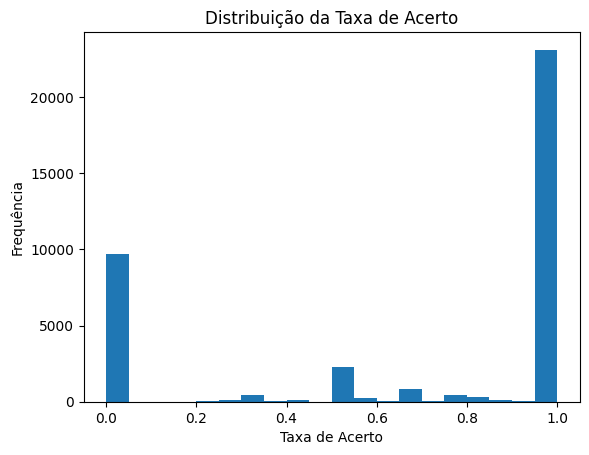

In [7]:
import matplotlib.pyplot as plt

plt.hist(df_grouped['taxa_acerto'], bins=20)
plt.title("Distribuição da Taxa de Acerto")
plt.xlabel("Taxa de Acerto")
plt.ylabel("Frequência")
plt.show()

Desempenho por habilidade

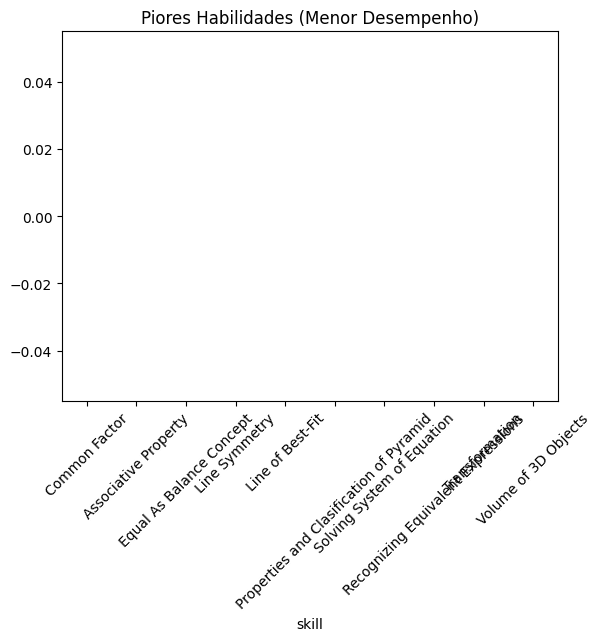

In [8]:
skill_performance = df_grouped.groupby('skill')['taxa_acerto'].mean().sort_values()

skill_performance.head(10).plot(kind='bar')
plt.title("Piores Habilidades (Menor Desempenho)")
plt.xticks(rotation=45)
plt.show()

Tempo vs desempenho

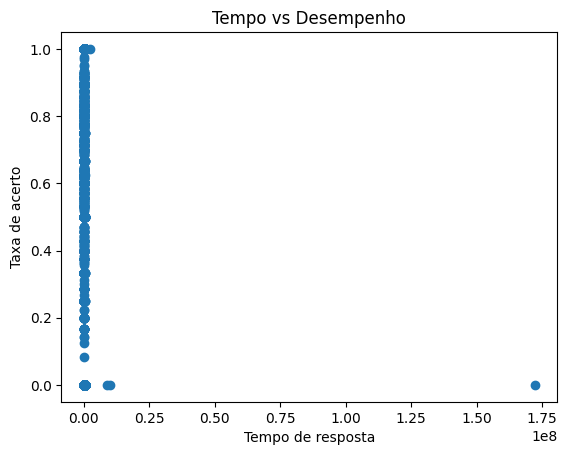

In [9]:
plt.scatter(df_grouped['tempo_resposta'], df_grouped['taxa_acerto'])
plt.xlabel("Tempo de resposta")
plt.ylabel("Taxa de acerto")
plt.title("Tempo vs Desempenho")
plt.show()

Dicas vs desempenho

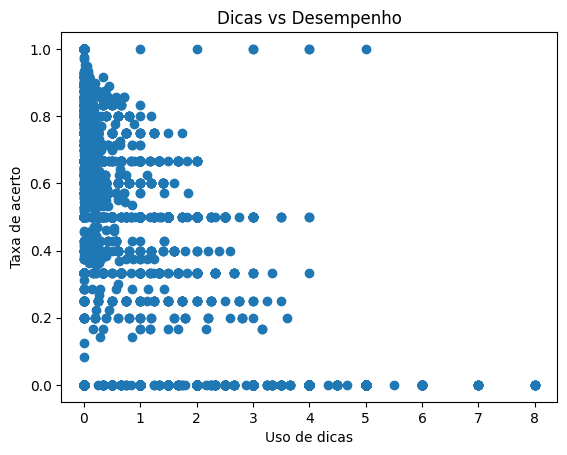

In [10]:
plt.scatter(df_grouped['dicas'], df_grouped['taxa_acerto'])
plt.xlabel("Uso de dicas")
plt.ylabel("Taxa de acerto")
plt.title("Dicas vs Desempenho")
plt.show()

Score de dificuldade

In [11]:
df_grouped['score_dificuldade'] = (
    (1 - df_grouped['taxa_acerto']) * 0.5 +
    df_grouped['tentativas'] * 0.2 +
    df_grouped['tempo_resposta'] * 0.00001 +
    df_grouped['dicas'] * 0.3
)

In [12]:
df_grouped.sort_values('score_dificuldade', ascending=False).head(10)

,user_id,skill,taxa_acerto,tentativas,tempo_resposta,dicas,score_dificuldade
17514,179349,Order of Operations All,0.0,2.00,172204271.5,2.0,1723.542715
618,93780,Equation Solving More Than Two Steps,0.0,2.00,10080000.0,0.0,101.700000
9611,172568,Equation Solving More Than Two Steps,0.0,2.00,8689331.0,0.0,87.793310
12450,175633,Unknown,1.0,1.25,2542847.5,0.0,25.678475
6385,138645,Addition and Subtraction Fractions,0.0,25.00,313466.0,2.0,9.234660
12567,175770,Polynomial Factors,0.0,4.00,591852.0,4.0,8.418520
20676,182709,Write Linear Equation from Ordered Pairs,0.0,1.00,584259.0,5.0,8.042590
37788,226743,Addition and Subtraction Fractions,0.0,16.00,368890.0,2.0,7.988900
12524,175709,Area Irregular Figure,0.0,3.00,565700.0,4.0,7.957000
7088,150755,Volume Cone,0.0,10.00,447160.0,3.0,7.871600
